In [3]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')

from tensorflow.keras import backend as K
import gc

K.clear_session()
gc.collect()

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 4050 Laptop GPU, compute capability 8.9


42

In [20]:
import os
import numpy as np
import pandas as pd

DATASET_DIR = r'dataset_casualities\train'

IMG_HEIGHT = 240 # EfficientNetB4 default input
IMG_WIDTH = 240
BATCH_SIZE = 16   # Adjust based on available RAM/GPU
NUM_CLASSES = 4
N_SPLITS = 5
EPOCHS_HEAD = 5
EPOCHS_FINE_TUNE = 10
LEARNING_RATE_HEAD = 1e-3
LEARNING_RATE_FINE_TUNE = 1e-5
DROPOUT_RATE = 0.5

In [21]:
from sklearn.utils import shuffle

image_paths, labels = [], []
class_names = sorted(os.listdir(DATASET_DIR))
class_to_idx = {name: i for i, name in enumerate(class_names)}

for class_name in class_names:
    class_dir = os.path.join(DATASET_DIR, class_name)
    for img_name in os.listdir(class_dir):
        if img_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            image_paths.append(os.path.join(class_dir, img_name))
            labels.append(class_to_idx[class_name])

image_paths = np.array(image_paths)
labels = np.array(labels)
image_paths, labels = shuffle(image_paths, labels, random_state=42)

In [22]:
class_to_idx

{'accident': 0, 'fire': 1, 'flood': 2, 'no_casuality': 3}

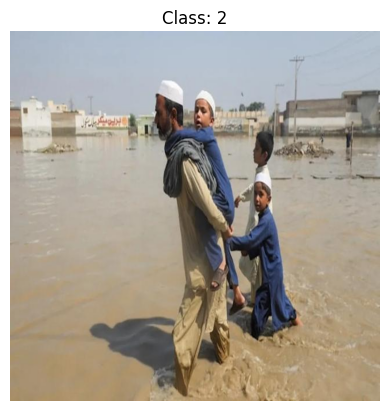

In [23]:
from PIL import Image
import matplotlib.pyplot as plt
img = Image.open(image_paths[3])
plt.imshow(img)
plt.title(f"Class: {labels[3]}")
plt.axis('off')
plt.show()

In [24]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weight_dict = dict(enumerate(class_weights))

In [25]:
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

def create_model(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3), num_classes=NUM_CLASSES, dropout_rate=DROPOUT_RATE):
    base_model = EfficientNetB4(weights='imagenet', include_top=False, input_shape=input_shape)
    base_model.trainable = False
    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = Dropout(dropout_rate)(x)
    output = Dense(num_classes, activation='softmax')(x)
    model = Model(inputs=base_model.input, outputs=output)
    return model

In [26]:
from sklearn.model_selection import StratifiedKFold
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from sklearn.metrics import classification_report

skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=42)
fold_accuracies = []
fold_f1_scores = []
fold_reports = []

for fold, (train_idx, val_idx) in enumerate(skf.split(image_paths, labels)):
    print(f"\n--- Fold {fold+1}/{N_SPLITS} ---")
    train_paths, train_labels = image_paths[train_idx], labels[train_idx]
    val_paths, val_labels = image_paths[val_idx], labels[val_idx]

    preprocess_input = tf.keras.applications.efficientnet.preprocess_input

    train_datagen = ImageDataGenerator(
        preprocessing_function=preprocess_input,
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )
    val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

    train_generator = train_datagen.flow_from_dataframe(
        pd.DataFrame({'filename': train_paths, 'class': train_labels.astype(str)}),
        x_col='filename',
        y_col='class',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True,
        classes=[str(i) for i in range(NUM_CLASSES)]
    )
    val_generator = val_datagen.flow_from_dataframe(
        pd.DataFrame({'filename': val_paths, 'class': val_labels.astype(str)}),
        x_col='filename',
        y_col='class',
        target_size=(IMG_HEIGHT, IMG_WIDTH),
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=False,
        classes=[str(i) for i in range(NUM_CLASSES)]
    )

    model = create_model()

    early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)
    checkpoint = ModelCheckpoint(f'best_model_fold_{fold+1}.keras', monitor='val_accuracy', save_best_only=True,save_weights_only=True, mode='max', verbose=1)

    # Train head only
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_HEAD),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.fit(
        train_generator,
        epochs=EPOCHS_HEAD,
        validation_data=val_generator,
        callbacks=[early_stopping, reduce_lr, checkpoint],
        class_weight=class_weight_dict
    )
    model.load_weights(f'best_model_fold_{fold+1}.keras')

    # Fine-tune all layers
    model.trainable = True
    model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE_FINE_TUNE),
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.fit(
        train_generator,
        epochs=EPOCHS_FINE_TUNE,
        validation_data=val_generator,
        callbacks=[early_stopping, reduce_lr, checkpoint],
        class_weight=class_weight_dict
    )
    model.load_weights(f'best_model_fold_{fold+1}.keras')

    # EvaluationF
    val_loss, val_accuracy = model.evaluate(val_generator, verbose=1)
    fold_accuracies.append(val_accuracy)
    pred_probs = model.predict(val_generator)
    pred_labels = np.argmax(pred_probs, axis=1)
    true_labels = val_generator.classes[val_generator.index_array]
    target_names = class_names

    report = classification_report(true_labels, pred_labels, target_names=target_names, output_dict=True)
    fold_f1_scores.append(report['weighted avg']['f1-score'])
    fold_reports.append(report)
    print(f"Fold {fold+1} Classification Report:\n{classification_report(true_labels, pred_labels, target_names=target_names)}")


--- Fold 1/5 ---
Found 40800 validated image filenames belonging to 4 classes.
Found 10200 validated image filenames belonging to 4 classes.
Epoch 1/5
2550/2550 [==============================] - ETA: 0s - loss: 0.1946 - accuracy: 0.9327
Epoch 1: val_accuracy improved from -inf to 0.97314, saving model to best_model_fold_1.keras
2550/2550 [==============================] - 791s 304ms/step - loss: 0.1946 - accuracy: 0.9327 - val_loss: 0.0851 - val_accuracy: 0.9731 - lr: 0.0010
Epoch 2/5
2550/2550 [==============================] - ETA: 0s - loss: 0.1334 - accuracy: 0.9537
Epoch 2: val_accuracy did not improve from 0.97314
2550/2550 [==============================] - 610s 239ms/step - loss: 0.1334 - accuracy: 0.9537 - val_loss: 0.0853 - val_accuracy: 0.9728 - lr: 0.0010
Epoch 3/5
2550/2550 [==============================] - ETA: 0s - loss: 0.1214 - accuracy: 0.9595
Epoch 3: val_accuracy did not improve from 0.97314
2550/2550 [==============================] - 604s 237ms/step - loss: 0.1

TypeError: only integer scalar arrays can be converted to a scalar index

In [27]:
print("\n--- Cross-Validation Summary ---")
print(f"Average Accuracy across {N_SPLITS} folds: {np.mean(fold_accuracies):.4f} ± {np.std(fold_accuracies):.4f}")
print(f"Average Weighted F1-Score across {N_SPLITS} folds: {np.mean(fold_f1_scores):.4f} ± {np.std(fold_f1_scores):.4f}")


--- Cross-Validation Summary ---
Average Accuracy across 5 folds: 0.9900 ± 0.0000
Average Weighted F1-Score across 5 folds: nan ± nan


D:\Softwares\Anaconda3\envs\new\lib\site-packages\numpy\core\fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
D:\Softwares\Anaconda3\envs\new\lib\site-packages\numpy\core\_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
D:\Softwares\Anaconda3\envs\new\lib\site-packages\numpy\core\_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
D:\Softwares\Anaconda3\envs\new\lib\site-packages\numpy\core\_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
D:\Softwares\Anaconda3\envs\new\lib\site-packages\numpy\core\_methods.py:261: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


In [29]:
# Optional: See detailed fold reports
for i, report in enumerate(fold_reports):
    print(f"\nReport for Fold {i+1}:")
    print(report)

## Testing Model

In [30]:
import os
import numpy as np
import pandas as pd
from tensorflow.keras.preprocessing.image import ImageDataGenerator

TEST_DIR = 'dataset_casualities/test'  # Change to the path of your "test" directory
IMG_HEIGHT = 380  # Use same size as during training
IMG_WIDTH = 380
BATCH_SIZE = 16  # Can adjust for your system

# Get the sorted class names as during training
class_names = sorted([f for f in os.listdir(TEST_DIR) if os.path.isdir(os.path.join(TEST_DIR, f))])

test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.efficientnet.preprocess_input
)

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE,
    class_mode='categorical',   # Should match training generator
    shuffle=False  # Important for correct y_true order
)

Found 10814 images belonging to 4 classes.


In [9]:
from tensorflow.keras.models import load_model

# Load your best model (change filename as appropriate)
model = load_model('best_model_fold_1.keras')  # Example; replace with your best model

In [10]:
# Evaluate on the test set and print metrics from model.compile
results = model.evaluate(test_generator, verbose=1)
print("\nTest Results:")
for name, value in zip(model.metrics_names, results):
    print(f"{name}: {value:.4f}")

130/130 [==============================] - 81s 543ms/step - loss: 0.0727 - accuracy: 0.9822

Test Results:
loss: 0.0727
accuracy: 0.9822


676/676 [==============================] - 242s 358ms/step
Classification Report:
               precision    recall  f1-score   support

    accident       0.98      0.99      0.98      1191
        fire       1.00      0.99      0.99      3989
       flood       1.00      0.99      0.99      4610
no_casuality       0.95      1.00      0.97      1024

    accuracy                           0.99     10814
   macro avg       0.98      0.99      0.98     10814
weighted avg       0.99      0.99      0.99     10814



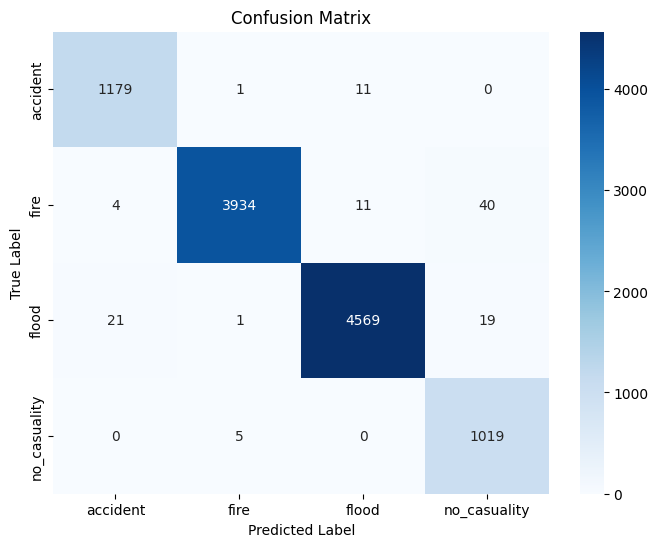

In [31]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Predict classes for the test set
pred_probs = model.predict(test_generator)
y_pred = np.argmax(pred_probs, axis=1)
y_true = test_generator.classes

# Classification report: precision, recall, f1-score
cr = classification_report(y_true, y_pred, target_names=class_names)
print("Classification Report:\n", cr)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Optionally: plot the confusion matrix
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

## Inference on unseen data

In [32]:
import numpy as np
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import tensorflow as tf

In [46]:
# List of your class names in correct order (used during training/testing)
class_names = ['Accident Detected', 'Fire Detected','Flood Detected', 'No Casuality']

# Path to your best trained EfficientNetB4 model
MODEL_PATH = 'best_model_fold_1.keras'
# Path to your single test image
SINGLE_IMAGE_PATH = 'images/image1.jpg'


In [47]:
model = create_model()
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=float(LEARNING_RATE_HEAD)))
model.load_weights(MODEL_PATH)

In [48]:
img = image.load_img(SINGLE_IMAGE_PATH, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = image.img_to_array(img)           # Convert image to numpy array
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)  # Preprocess image for EfficientNet

In [49]:
pred_probs = model.predict(img_array)
pred_class_idx = np.argmax(pred_probs, axis=1)[0]
pred_class_name = class_names[pred_class_idx]

print(f"Predicted class: {pred_class_name}")
print(f"Prediction probabilities (per class): {pred_probs[0]}")

ValueError: in user code:

    File "D:\Softwares\Anaconda3\envs\new\lib\site-packages\keras\engine\training.py", line 2041, in predict_function  *
        return step_function(self, iterator)
    File "D:\Softwares\Anaconda3\envs\new\lib\site-packages\keras\engine\training.py", line 2027, in step_function  **
        outputs = model.distribute_strategy.run(run_step, args=(data,))
    File "D:\Softwares\Anaconda3\envs\new\lib\site-packages\keras\engine\training.py", line 2015, in run_step  **
        outputs = model.predict_step(data)
    File "D:\Softwares\Anaconda3\envs\new\lib\site-packages\keras\engine\training.py", line 1983, in predict_step
        return self(x, training=False)
    File "D:\Softwares\Anaconda3\envs\new\lib\site-packages\keras\utils\traceback_utils.py", line 70, in error_handler
        raise e.with_traceback(filtered_tb) from None
    File "D:\Softwares\Anaconda3\envs\new\lib\site-packages\keras\engine\input_spec.py", line 295, in assert_input_compatibility
    

In [23]:
SINGLE_IMAGE_PATH = 'image2.jpg'
img = image.load_img(SINGLE_IMAGE_PATH, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = image.img_to_array(img)           # Convert image to numpy array
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)  # Preprocess image for EfficientNet
pred_probs = model.predict(img_array)
pred_class_idx = np.argmax(pred_probs, axis=1)[0]
pred_class_name = class_names[pred_class_idx]

print(f"Predicted class: {pred_class_name}")
print(f"Prediction probabilities (per class): {pred_probs[0]}")

1/1 [==============================] - 0s 63ms/step
Predicted class: Fire Detected
Prediction probabilities (per class): [2.3671148e-05 9.9997520e-01 5.3672375e-07 5.0635930e-07]


In [25]:
SINGLE_IMAGE_PATH = 'image4.jpg'
img = image.load_img(SINGLE_IMAGE_PATH, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = image.img_to_array(img)           # Convert image to numpy array
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)  # Preprocess image for EfficientNet
pred_probs = model.predict(img_array)
pred_class_idx = np.argmax(pred_probs, axis=1)[0]
pred_class_name = class_names[pred_class_idx]

print(f"Predicted class: {pred_class_name}")
print(f"Prediction probabilities (per class): {pred_probs[0]}")

1/1 [==============================] - 0s 69ms/step
Predicted class: No Casuality
Prediction probabilities (per class): [8.1491919e-05 1.6664083e-03 1.4528088e-02 9.8372400e-01]


In [26]:
SINGLE_IMAGE_PATH = 'image5.jpg'
img = image.load_img(SINGLE_IMAGE_PATH, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = image.img_to_array(img)           # Convert image to numpy array
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)  # Preprocess image for EfficientNet
pred_probs = model.predict(img_array)
pred_class_idx = np.argmax(pred_probs, axis=1)[0]
pred_class_name = class_names[pred_class_idx]

print(f"Predicted class: {pred_class_name}")
print(f"Prediction probabilities (per class): {pred_probs[0]}")

1/1 [==============================] - 0s 66ms/step
Predicted class: No Casuality
Prediction probabilities (per class): [6.2083716e-05 1.4518430e-03 5.7114894e-03 9.9277461e-01]


In [27]:
SINGLE_IMAGE_PATH = 'image6.jpg'
img = image.load_img(SINGLE_IMAGE_PATH, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = image.img_to_array(img)           # Convert image to numpy array
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)  # Preprocess image for EfficientNet
pred_probs = model.predict(img_array)
pred_class_idx = np.argmax(pred_probs, axis=1)[0]
pred_class_name = class_names[pred_class_idx]

print(f"Predicted class: {pred_class_name}")
print(f"Prediction probabilities (per class): {pred_probs[0]}")

1/1 [==============================] - 0s 73ms/step
Predicted class: Fire Detected
Prediction probabilities (per class): [4.8145143e-06 9.7694230e-01 1.9656766e-06 2.3050936e-02]


In [28]:
SINGLE_IMAGE_PATH = 'image7.jpg'
img = image.load_img(SINGLE_IMAGE_PATH, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = image.img_to_array(img)           # Convert image to numpy array
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)  # Preprocess image for EfficientNet
pred_probs = model.predict(img_array)
pred_class_idx = np.argmax(pred_probs, axis=1)[0]
pred_class_name = class_names[pred_class_idx]

print(f"Predicted class: {pred_class_name}")
print(f"Prediction probabilities (per class): {pred_probs[0]}")

1/1 [==============================] - 0s 64ms/step
Predicted class: Fire Detected
Prediction probabilities (per class): [1.9372062e-16 1.0000000e+00 2.2250086e-19 6.1493844e-13]


In [29]:
SINGLE_IMAGE_PATH = 'image8.jpg'
img = image.load_img(SINGLE_IMAGE_PATH, target_size=(IMG_HEIGHT, IMG_WIDTH))
img_array = image.img_to_array(img)           # Convert image to numpy array
img_array = np.expand_dims(img_array, axis=0) # Add batch dimension
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)  # Preprocess image for EfficientNet
pred_probs = model.predict(img_array)
pred_class_idx = np.argmax(pred_probs, axis=1)[0]
pred_class_name = class_names[pred_class_idx]

print(f"Predicted class: {pred_class_name}")
print(f"Prediction probabilities (per class): {pred_probs[0]}")

1/1 [==============================] - 0s 60ms/step
Predicted class: Fire Detected
Prediction probabilities (per class): [2.6383767e-10 9.9999988e-01 2.1873068e-11 7.6381475e-08]
